In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

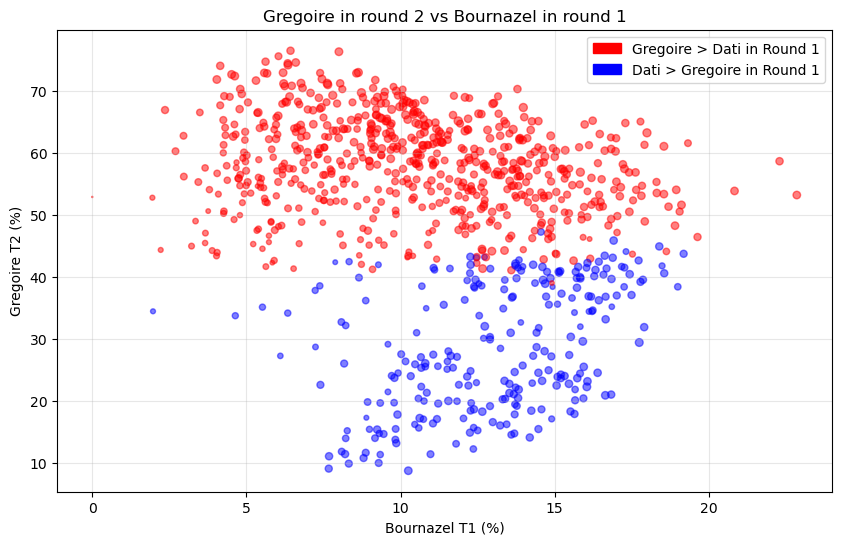

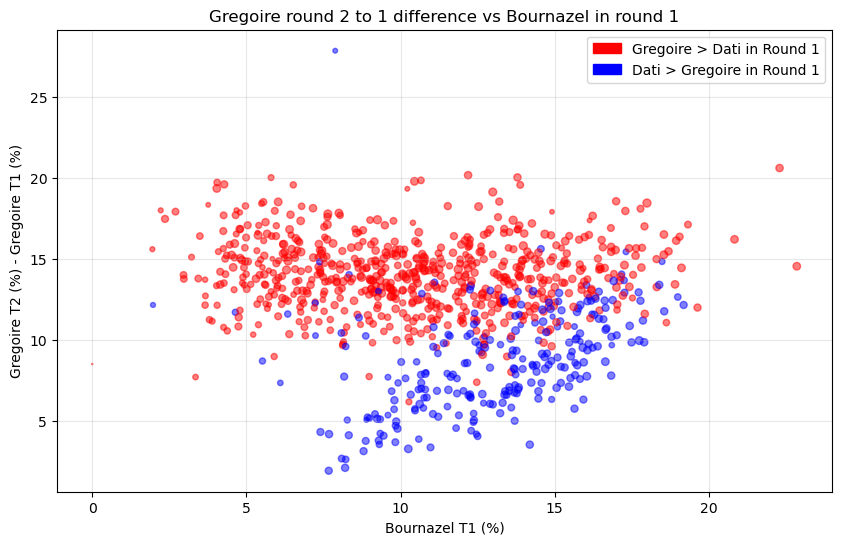

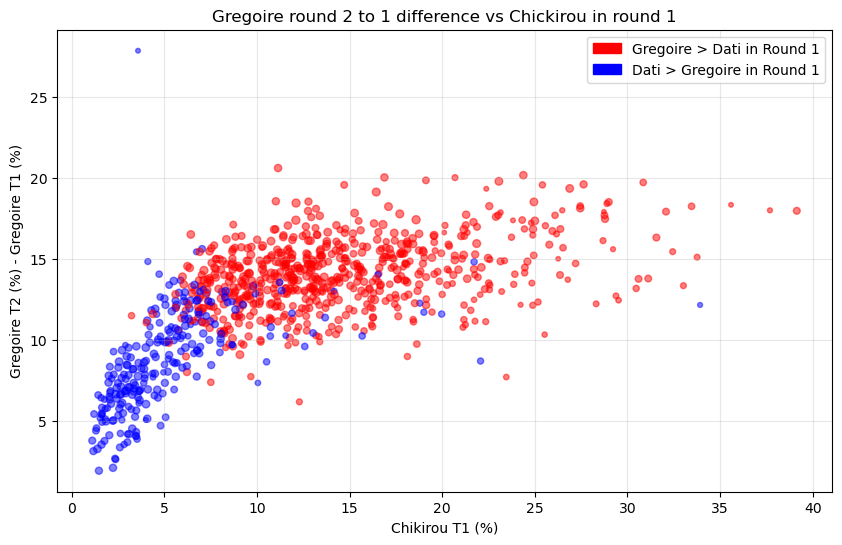

In [53]:
# Load datasets
df1 = pd.read_csv('municipales26_tour1_paris.csv', encoding='utf-8', sep = ';')
df2 = pd.read_csv('municipales26_tour2_paris.csv', encoding='utf-8', sep = ';')
# remove unwanted spaces from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

col_x = '% Voix/exprimes 6'
col_y = '% Voix/exprimes 1'

# plot colors according to voting behaviour in round 1
gregoire_round1 = pd.to_numeric(df1['% Voix/exprimes 3'].astype(str).str.replace(',', '.'), errors='coerce')
dati_round1 = pd.to_numeric(df1['% Voix/exprimes 7'].astype(str).str.replace(',', '.'), errors='coerce')

sizes = pd.to_numeric(df1['Votants'], errors='coerce').fillna(0)
sizes = sizes/np.max(sizes)
#modify dot sizes by number of registered voters
scale_factor = 35

colors = np.where(gregoire_round1 > dati_round1, 'red', 'blue')

plt.figure(figsize=(10, 6))
plt.title('Gregoire in round 2 vs Bournazel in round 1')
plt.scatter(df1[col_x], df2[col_y], c = colors, s = sizes*scale_factor,alpha=0.5)
plt.xlabel(f'Bournazel T1 (%)')
plt.ylabel(f'Gregoire T2 (%)')
plt.grid(True, alpha=0.3)
# legend 
red_patch = mpatches.Patch(color='red', label='Gregoire > Dati in Round 1')
blue_patch = mpatches.Patch(color='blue', label='Dati > Gregoire in Round 1')
plt.legend(handles=[red_patch, blue_patch], loc='best')
plt.show()

# now plot the percent difference for Gregoire in the second round. for a finer study should take abstension into account. 
# but this is ok to that a first look at

plt.figure(figsize=(10, 6))
plt.title('Gregoire round 2 to 1 difference vs Bournazel in round 1')
plt.scatter(df1[col_x], df2[col_y] - gregoire_round1, c = colors, s = sizes*scale_factor,alpha=0.5)
plt.xlabel(f'Bournazel T1 (%)')
plt.ylabel(f'Gregoire T2 (%) - Gregoire T1 (%)')
plt.legend(handles=[red_patch, blue_patch], loc='best')
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))
plt.title('Gregoire round 2 to 1 difference vs Chickirou in round 1')
plt.scatter(df1['% Voix/exprimes 8'], df2[col_y] - gregoire_round1, c = colors, s = sizes*scale_factor,alpha=0.5)
plt.xlabel(f'Chikirou T1 (%)')
plt.ylabel(f'Gregoire T2 (%) - Gregoire T1 (%)')
plt.legend(handles=[red_patch, blue_patch], loc='best')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# so we see that for the coming analyses we have to distinguish 2 separate datasets: t
# hose where Gregoire won in the first round and those where Dati won in the first round 